In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from summarytools import dfSummary
from skimpy import skim
import os

# About the dataset

## Walmart M5 Forecasting dataset.

# EDA
## Exploring the dataset. 

In [2]:
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
sales = pd.read_csv("dataset/sales_train_evaluation.csv")
calender = pd.read_csv("dataset/calendar.csv")
sprice = pd.read_csv("dataset/sell_prices.csv")

### Focusing on only the Hobbies items

In [3]:
sales = sales[sales.cat_id == "HOBBIES"]

In [4]:
calender.shape, sprice.shape

((1969, 14), (6841121, 4))

In [5]:
sales['item_id'].value_counts()

item_id
HOBBIES_1_001    10
HOBBIES_1_002    10
HOBBIES_1_003    10
HOBBIES_1_004    10
HOBBIES_1_005    10
                 ..
HOBBIES_2_145    10
HOBBIES_2_146    10
HOBBIES_2_147    10
HOBBIES_2_148    10
HOBBIES_2_149    10
Name: count, Length: 565, dtype: int64

In [6]:
calender['event_type_1'].value_counts()

event_type_1
Religious    55
National     52
Cultural     37
Sporting     18
Name: count, dtype: int64

In [7]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [8]:
ids = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

In [9]:
# Merging the days into rows from columns for readability
long = sales.melt(id_vars = ids, var_name = "d", value_name = "units")

In [10]:
long['d'].value_counts()

d
d_1       5650
d_2       5650
d_3       5650
d_4       5650
d_5       5650
          ... 
d_1937    5650
d_1938    5650
d_1939    5650
d_1940    5650
d_1941    5650
Name: count, Length: 1941, dtype: int64

In [11]:
long[long['d'] == "d_1"]

,id,item_id,dept_id,cat_id,store_id,state_id,d,units
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
...,...,...,...,...,...,...,...,...
5645,HOBBIES_2_145_WI_3_evaluation,HOBBIES_2_145,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0
5646,HOBBIES_2_146_WI_3_evaluation,HOBBIES_2_146,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0
5647,HOBBIES_2_147_WI_3_evaluation,HOBBIES_2_147,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0
5648,HOBBIES_2_148_WI_3_evaluation,HOBBIES_2_148,HOBBIES_2,HOBBIES,WI_3,WI,d_1,0


In [12]:
sales.dtypes

id            str
item_id       str
dept_id       str
cat_id        str
store_id      str
            ...  
d_1937      int64
d_1938      int64
d_1939      int64
d_1940      int64
d_1941      int64
Length: 1947, dtype: object

In [13]:
long.dtypes

id            str
item_id       str
dept_id       str
cat_id        str
store_id      str
state_id      str
d             str
units       int64
dtype: object

In [14]:
# Turning the columns into categories as well as appropriate data type to save space.

for c in ids[1:]:
    long[c] = long[c].astype("category")
long["d"] = long["d"].str[2:].astype("int16")
calender['d'] = calender['d'].str[2:].astype('int16')
long["units"] = long["units"].astype("int16")

In [15]:
long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0


In [16]:
long.dtypes

id               str
item_id     category
dept_id     category
cat_id      category
store_id    category
state_id    category
d              int16
units          int16
dtype: object

In [17]:
first_sale = long[long.units > 0].groupby("id", observed=True)["d"].min()

In [18]:
print(f"Long shape before: {long.shape}")
print(f"Long shape after: {first_sale.shape}")

Long shape before: (10966650, 8)
Long shape after: (5650,)


In [19]:
long[long.units > 0].groupby("id", observed=True)["d"].min()

id
HOBBIES_1_001_CA_1_evaluation    902
HOBBIES_1_001_CA_2_evaluation    911
HOBBIES_1_001_CA_3_evaluation    910
HOBBIES_1_001_CA_4_evaluation    901
HOBBIES_1_001_TX_1_evaluation    900
                                ... 
HOBBIES_2_149_TX_2_evaluation    846
HOBBIES_2_149_TX_3_evaluation    844
HOBBIES_2_149_WI_1_evaluation    834
HOBBIES_2_149_WI_2_evaluation    935
HOBBIES_2_149_WI_3_evaluation    883
Name: d, Length: 5650, dtype: int16

In [20]:
n_pairs = sprice.groupby(["store_id","item_id"]).ngroups
n_weeks = sprice.wm_yr_wk.nunique()
print("if rectangular:", n_pairs * n_weeks, "   actual rows:", len(sprice))

if rectangular: 8598180    actual rows: 6841121


In [21]:
hsprice = sprice[sprice["item_id"].str.contains("HOBBIES")]
hsprice

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6274446,WI_3,HOBBIES_2_149,11617,0.97
6274447,WI_3,HOBBIES_2_149,11618,0.97
6274448,WI_3,HOBBIES_2_149,11619,0.97
6274449,WI_3,HOBBIES_2_149,11620,0.97


In [22]:
hsprice.shape

(1283905, 4)

In [23]:
count = hsprice.groupby(["store_id", "item_id"])["wm_yr_wk"].nunique() 
count

store_id  item_id      
CA_1      HOBBIES_1_001    154
          HOBBIES_1_002    262
          HOBBIES_1_003    125
          HOBBIES_1_004    277
          HOBBIES_1_005    266
                          ... 
WI_3      HOBBIES_2_145    280
          HOBBIES_2_146    282
          HOBBIES_2_147    161
          HOBBIES_2_148    282
          HOBBIES_2_149    156
Name: wm_yr_wk, Length: 5650, dtype: int64

In [24]:
count.shape

(5650,)

In [25]:
n_pairs = hsprice.groupby(["store_id","item_id"]).ngroups
n_weeks = hsprice.wm_yr_wk.nunique()
print("if rectangular:", n_pairs * n_weeks, "\nactual:", len(hsprice))

if rectangular: 1593300 
actual: 1283905


In [26]:
n_pairs, n_weeks

(5650, 282)

In [27]:
counts = hsprice.groupby(["store_id","item_id"])["wm_yr_wk"].nunique()
print(counts.value_counts().sort_index())   # how many pairs have how many weeks

wm_yr_wk
34        1
47        2
48        3
50        3
51        1
       ... 
278      24
279      57
280     137
281     251
282    1853
Name: count, Length: 222, dtype: int64


In [28]:
print(counts.sort_values().head(20))        # the SHORTEST-lived products

store_id  item_id      
CA_4      HOBBIES_1_170    34
          HOBBIES_2_132    47
WI_3      HOBBIES_1_170    47
          HOBBIES_2_132    48
TX_2      HOBBIES_2_132    48
CA_4      HOBBIES_1_063    48
WI_1      HOBBIES_2_132    50
CA_1      HOBBIES_2_132    50
CA_2      HOBBIES_2_132    50
CA_4      HOBBIES_1_234    51
TX_1      HOBBIES_2_026    59
WI_3      HOBBIES_2_026    60
TX_2      HOBBIES_2_026    61
TX_3      HOBBIES_2_026    61
CA_2      HOBBIES_2_026    61
WI_1      HOBBIES_2_041    62
          HOBBIES_2_026    62
CA_4      HOBBIES_2_041    63
          HOBBIES_2_026    65
          HOBBIES_1_274    65
Name: wm_yr_wk, dtype: int64


In [29]:
all_weeks = set(hsprice.wm_yr_wk.unique())
one = hsprice[(hsprice.store_id=="CA_1") & (hsprice.item_id=="HOBBIES_1_170")]
one

,store_id,item_id,wm_yr_wk,sell_price
38256,CA_1,HOBBIES_1_170,11326,17.97
38257,CA_1,HOBBIES_1_170,11327,17.97
38258,CA_1,HOBBIES_1_170,11328,17.97
38259,CA_1,HOBBIES_1_170,11329,17.97
38260,CA_1,HOBBIES_1_170,11330,17.97
...,...,...,...,...
38404,CA_1,HOBBIES_1_170,11617,17.97
38405,CA_1,HOBBIES_1_170,11618,17.97
38406,CA_1,HOBBIES_1_170,11619,17.97
38407,CA_1,HOBBIES_1_170,11620,17.97


In [30]:
long.dtypes

id               str
item_id     category
dept_id     category
cat_id      category
store_id    category
state_id    category
d              int16
units          int16
dtype: object

In [31]:
calender.dtypes

date              str
wm_yr_wk        int64
weekday           str
wday            int64
month           int64
year            int64
d               int16
event_name_1      str
event_type_1      str
event_name_2      str
event_type_2      str
snap_CA         int64
snap_TX         int64
snap_WI         int64
dtype: object

In [32]:
s1 = long.merge(calender[["d", "wm_yr_wk"]], on="d", how="left")

In [33]:
s2 = s1.merge(hsprice, on=["store_id", "item_id", "wm_yr_wk"], how="left")

In [34]:
s2.isna().sum()

id                  0
item_id             0
dept_id             0
cat_id              0
store_id            0
state_id            0
d                   0
units               0
wm_yr_wk            0
sell_price    2165765
dtype: int64

In [35]:
s2.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN


<Axes: xlabel='dept_id'>

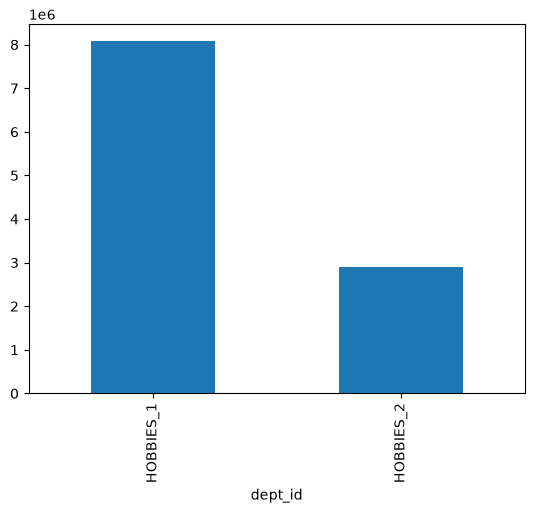

In [36]:
s2['dept_id'].value_counts().plot(kind = "bar")

In [37]:
print(f"Total number of rows", len(s2['sell_price']))
print(f"Missing values for sell price", s2['sell_price'].isna().sum())
print(f"Total items listed: {len(s2['sell_price'])} - {s2['sell_price'].isna().sum()} = {len(s2['sell_price']) - s2['sell_price'].isna().sum()}")

Total number of rows 10966650
Missing values for sell price 2165765
Total items listed: 10966650 - 2165765 = 8800885


In [38]:
hobbies1 = s2[s2['item_id'] == 'HOBBIES_1_001']
len(hobbies1)

19410

In [39]:
hobbies1['sell_price'].isna().sum()

np.int64(9044)

In [40]:
hobbies1

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN
565,HOBBIES_1_001_CA_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_2,CA,1,0,11101,NaN
1130,HOBBIES_1_001_CA_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_3,CA,1,0,11101,NaN
1695,HOBBIES_1_001_CA_4_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_4,CA,1,0,11101,NaN
2260,HOBBIES_1_001_TX_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_1,TX,1,0,11101,NaN
...,...,...,...,...,...,...,...,...,...,...
10963825,HOBBIES_1_001_TX_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_2,TX,1941,1,11617,8.26
10964390,HOBBIES_1_001_TX_3_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,TX_3,TX,1941,1,11617,8.26
10964955,HOBBIES_1_001_WI_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,WI_1,WI,1941,2,11617,8.38
10965520,HOBBIES_1_001_WI_2_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,WI_2,WI,1941,0,11617,8.38


In [41]:
# Safely assume that NaN in sell_price means the items was not on the shelf 
s2[(s2['sell_price'].isna()) & (s2['units'] > 0)]

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price


In [42]:
s2['Revenue Generated'] = s2['units'] * s2['sell_price']
s2['Revenue Generated'] = s2['Revenue Generated'].round(2)


In [43]:
s3 = s2.merge(calender, on = ['wm_yr_wk', 'd'], how = 'left')

In [44]:
s3.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [45]:
s3['date'] = pd.to_datetime(s3['date'], format='%Y-%m-%d')

# Step 4: Set Date as index
s3.set_index('date', inplace=True)

In [46]:
s3[['weekday', 'wday']]

,weekday,wday
date,,
2011-01-29,Saturday,1
2011-01-29,Saturday,1
2011-01-29,Saturday,1
2011-01-29,Saturday,1
2011-01-29,Saturday,1
...,...,...
2016-05-22,Sunday,2
2016-05-22,Sunday,2
2016-05-22,Sunday,2


In [47]:
s3.drop(columns = ['weekday'], inplace = True)

In [48]:
s3.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
date,,,,,,,,,,,,,,,,,,,,,
2011-01-29,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,NaN,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0


In [49]:
s3['store_id'].unique()

<ArrowStringArray>
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2',
 'WI_3']
Length: 10, dtype: str

### Items are evenly distributed throughout the all the stores

<Axes: >

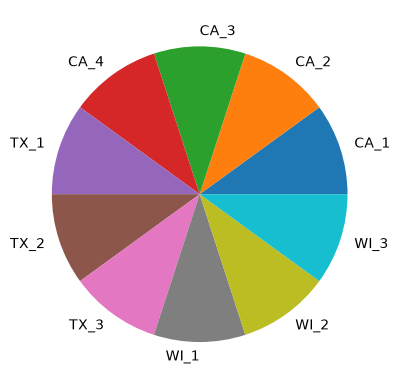

In [50]:
s3.groupby('store_id')['item_id'].count().plot(kind = "pie")

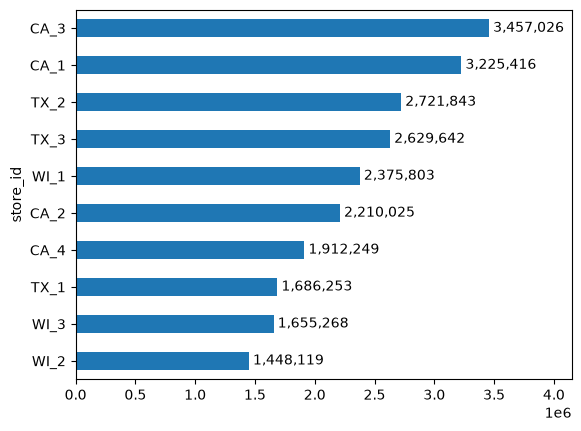

In [51]:
# revenue generated by store over the years

ax = (s3.groupby('store_id')['Revenue Generated'].sum().sort_values().plot(kind = "barh"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
ax.margins(x=0.2)          # stops the labels clipping off the right edge

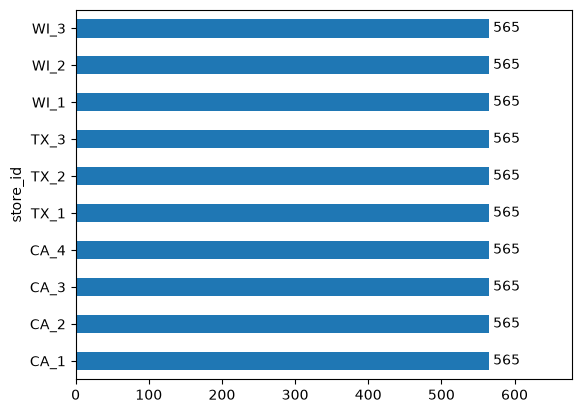

In [52]:
ax = (s3[s3.sell_price.notna()].groupby('store_id', observed=True)['item_id'].nunique().sort_values().plot(kind="barh"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
ax.margins(x=0.2)

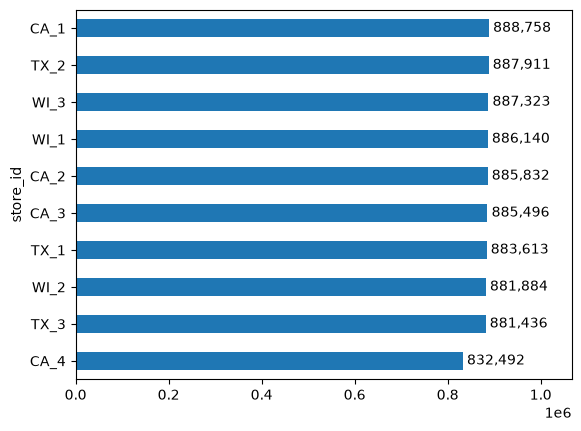

In [53]:
ax = (s3.groupby('store_id', observed=True)['sell_price']
        .count().sort_values().plot(kind="barh"))
ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=3)
ax.margins(x=0.2)          # stops the labels clipping off the right edge

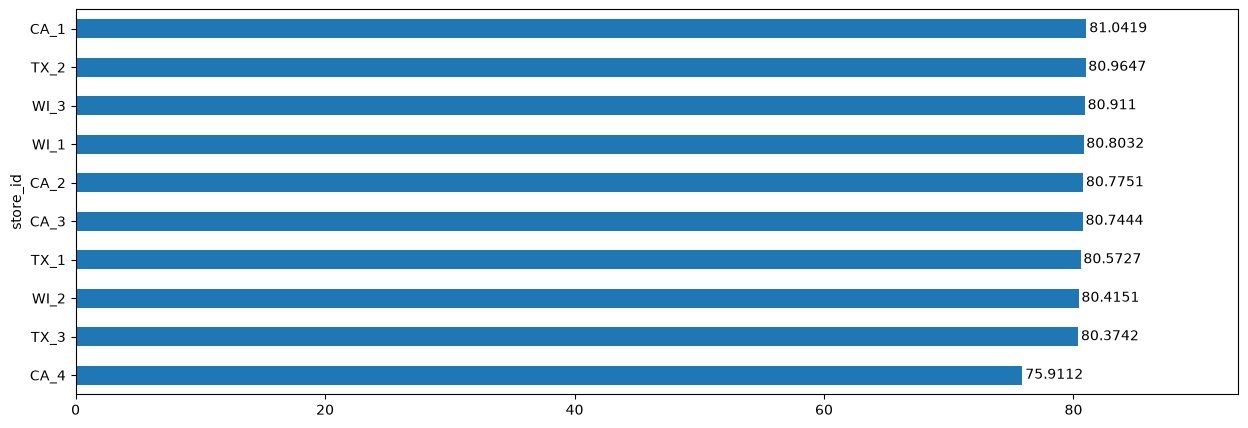

In [54]:
true_products = s3.groupby('store_id', observed=True)['sell_price'].size()
current_products = s3.groupby('store_id', observed=True)['sell_price'].count()
assort_breadth = ((current_products/true_products)* 100).sort_values().plot(kind = "barh", figsize = (15,5))
assort_breadth.bar_label(assort_breadth.containers[0], padding  = 2)
assort_breadth.margins(x = 0.15)


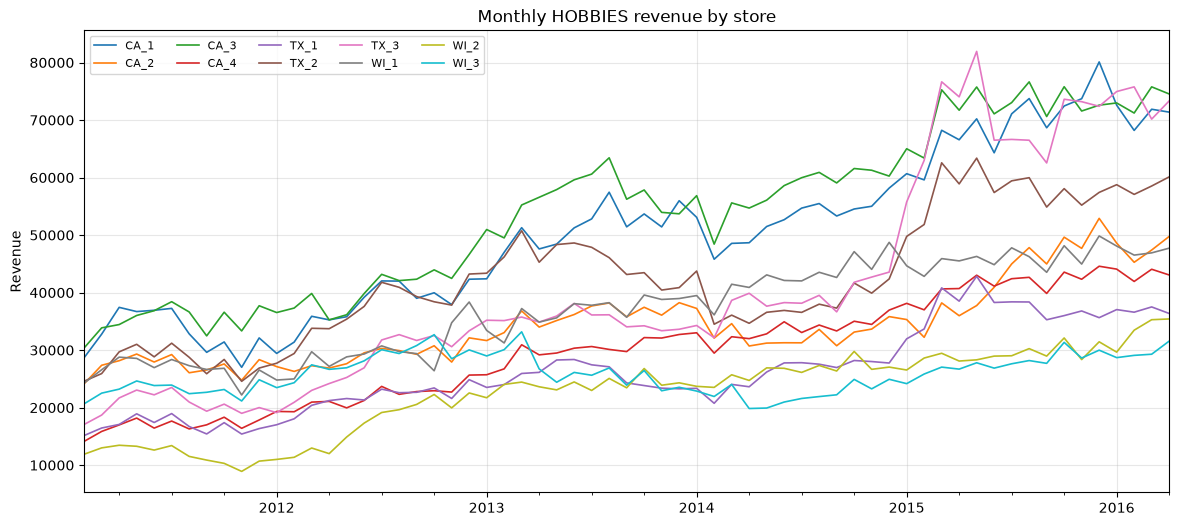

In [55]:
revenue_ot = s3.groupby([pd.Grouper(freq ="MS"),'store_id'], observed=True)['Revenue Generated'].sum().unstack("store_id")
ax = (revenue_ot.iloc[1:-1].plot(figsize=(14, 6), linewidth=1.2))

ax.set_title("Monthly HOBBIES revenue by store")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.legend(ncol=5, fontsize=8, title=None)
ax.grid(alpha=.3)

### Top 5 places where units sold through

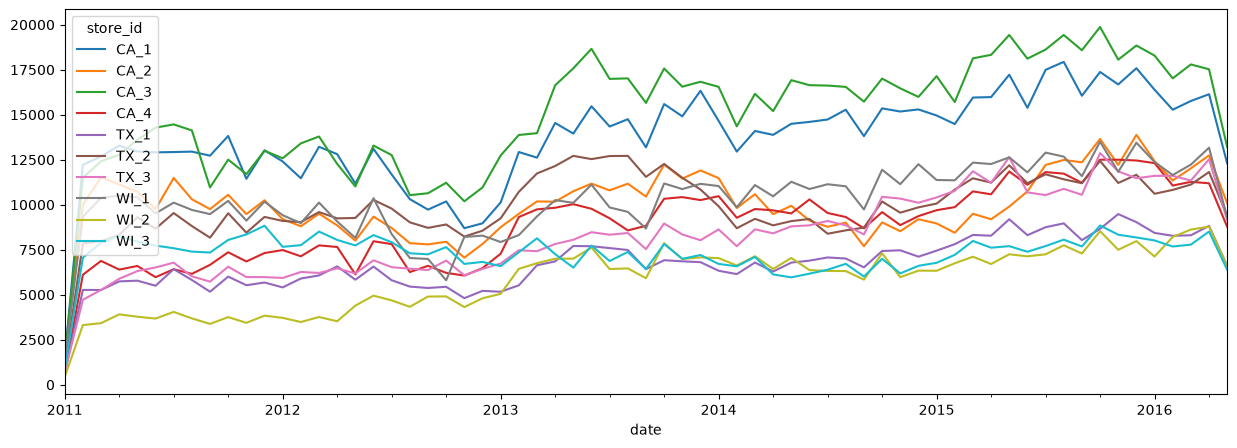

In [56]:
unitsold_ot = s3.groupby([pd.Grouper(freq="MS"), "store_id"], observed=True)["units"].sum().unstack("store_id")
ax = (unitsold_ot.plot(kind = "line", figsize = (15, 5)))

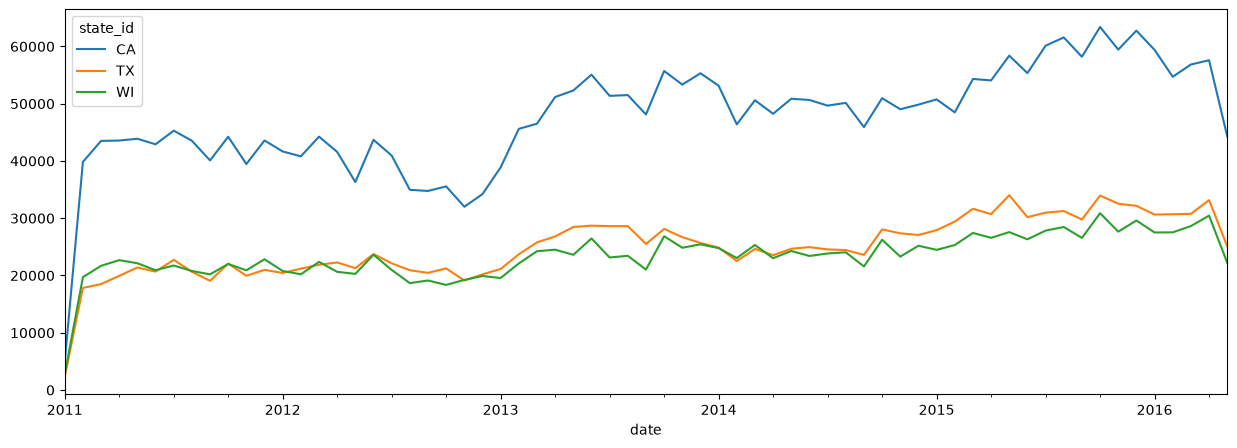

In [57]:
# Profitable state
unitsold_ot = s3.groupby([pd.Grouper(freq="MS"), "state_id"], observed=True)["units"].sum().unstack("state_id")
ax = (unitsold_ot.plot(kind = "line", figsize = (15, 5)))

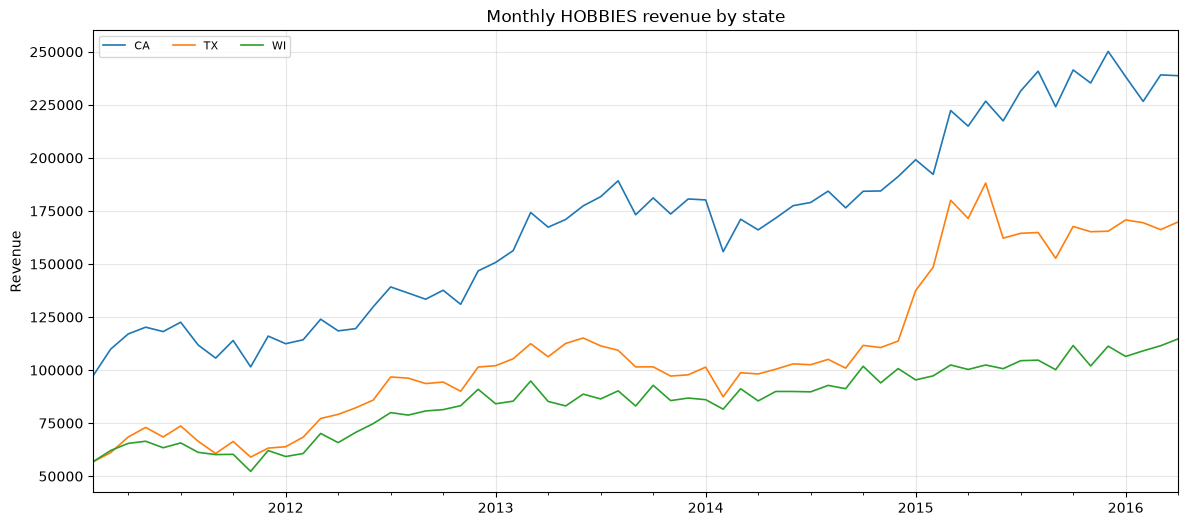

In [58]:
revenue_ot = s3.groupby([pd.Grouper(freq ="MS"),'state_id'], observed=True)['Revenue Generated'].sum().unstack("state_id")
ax = (revenue_ot.iloc[1:-1].plot(figsize=(14, 6), linewidth=1.2))

ax.set_title("Monthly HOBBIES revenue by state")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.legend(ncol=5, fontsize=8, title=None)
ax.grid(alpha=.3)

In [59]:
len(s3), len(s3[s3['Revenue Generated'].notna()])

(10966650, 8800885)

In [60]:
items_shelved = s3.groupby(['id'])['Revenue Generated'].count()
items_shelved

id
HOBBIES_1_001_CA_1_evaluation    1045
HOBBIES_1_001_CA_2_evaluation    1031
HOBBIES_1_001_CA_3_evaluation    1038
HOBBIES_1_001_CA_4_evaluation    1045
HOBBIES_1_001_TX_1_evaluation    1045
                                 ... 
HOBBIES_2_149_TX_2_evaluation    1101
HOBBIES_2_149_TX_3_evaluation    1101
HOBBIES_2_149_WI_1_evaluation    1108
HOBBIES_2_149_WI_2_evaluation    1010
HOBBIES_2_149_WI_3_evaluation    1059
Name: Revenue Generated, Length: 5650, dtype: int64

In [61]:
money_made = s3[s3['Revenue Generated'] > 0]
items_sold_count = money_made.groupby('id')['Revenue Generated'].count()
items_sold_count

id
HOBBIES_1_001_CA_1_evaluation    436
HOBBIES_1_001_CA_2_evaluation    377
HOBBIES_1_001_CA_3_evaluation    480
HOBBIES_1_001_CA_4_evaluation    459
HOBBIES_1_001_TX_1_evaluation    222
                                ... 
HOBBIES_2_149_TX_2_evaluation    236
HOBBIES_2_149_TX_3_evaluation    222
HOBBIES_2_149_WI_1_evaluation    211
HOBBIES_2_149_WI_2_evaluation    137
HOBBIES_2_149_WI_3_evaluation    146
Name: Revenue Generated, Length: 5650, dtype: int64

In [62]:
zero_units = round(1 - (items_sold_count/ items_shelved), 2)

In [63]:
zero_units.sort_values(ascending=False)

id
HOBBIES_2_030_CA_4_evaluation    0.98
HOBBIES_1_052_CA_3_evaluation    0.98
HOBBIES_1_052_CA_2_evaluation    0.98
HOBBIES_1_006_CA_4_evaluation    0.98
HOBBIES_1_217_TX_1_evaluation    0.98
                                 ... 
HOBBIES_1_323_TX_2_evaluation    0.08
HOBBIES_1_134_CA_1_evaluation    0.08
HOBBIES_1_387_CA_3_evaluation    0.07
HOBBIES_1_337_CA_3_evaluation    0.07
HOBBIES_1_158_TX_1_evaluation    0.02
Name: Revenue Generated, Length: 5650, dtype: float64

<Axes: ylabel='Frequency'>

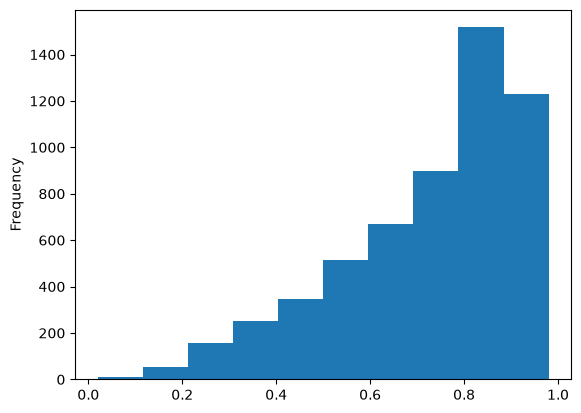

In [64]:
zero_units.plot(kind = "hist")

In [65]:
adi = round(items_shelved / items_sold_count, 2)
adi.describe()

count    5650.000000
mean        6.235317
std         5.601397
min         1.020000
25%         2.550000
50%         4.520000
75%         7.990000
max        64.700000
Name: Revenue Generated, dtype: float64

<Axes: ylabel='Frequency'>

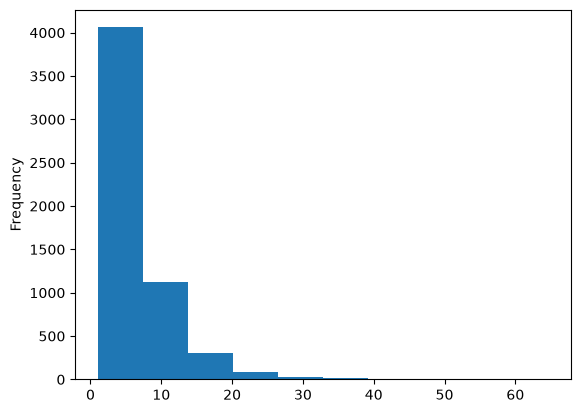

In [66]:
adi.plot(kind = "hist", )

In [67]:
units_obv_0 = s3[s3['units'] > 0]
calculation = units_obv_0.groupby('id')['units'].agg(['std', 'mean'])

In [68]:
cv2 = round((calculation['std']/ calculation['mean']) ** 2, 2)

<Axes: ylabel='Frequency'>

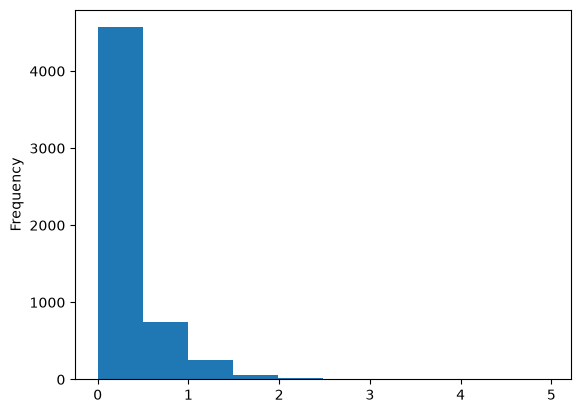

In [69]:
cv2.plot(kind = 'hist')

In [70]:
adi

id
HOBBIES_1_001_CA_1_evaluation    2.40
HOBBIES_1_001_CA_2_evaluation    2.73
HOBBIES_1_001_CA_3_evaluation    2.16
HOBBIES_1_001_CA_4_evaluation    2.28
HOBBIES_1_001_TX_1_evaluation    4.71
                                 ... 
HOBBIES_2_149_TX_2_evaluation    4.67
HOBBIES_2_149_TX_3_evaluation    4.96
HOBBIES_2_149_WI_1_evaluation    5.25
HOBBIES_2_149_WI_2_evaluation    7.37
HOBBIES_2_149_WI_3_evaluation    7.25
Name: Revenue Generated, Length: 5650, dtype: float64

In [71]:
combined_metrics = pd.concat([cv2, adi], axis = 1, keys = ['cv2', 'adi'])
combined_metrics

,cv2,adi
id,,
HOBBIES_1_001_CA_1_evaluation,0.28,2.40
HOBBIES_1_001_CA_2_evaluation,0.27,2.73
HOBBIES_1_001_CA_3_evaluation,0.30,2.16
HOBBIES_1_001_CA_4_evaluation,0.29,2.28
HOBBIES_1_001_TX_1_evaluation,0.20,4.71
...,...,...
HOBBIES_2_149_TX_2_evaluation,0.98,4.67
HOBBIES_2_149_TX_3_evaluation,0.60,4.96
HOBBIES_2_149_WI_1_evaluation,0.44,5.25


In [72]:
def sbc_class(row):
    """Syntetos-Boylan-Croston demand classification."""
    if row['adi'] < 1.32 and row['cv2'] < 0.49: 
        return "smooth"
    elif row['adi'] >= 1.32 and row['cv2'] < 0.49: 
        return "intermittent"
    elif row['adi'] < 1.32 and row['cv2'] >= 0.49: 
        return "erratic"
    else:
        return "lumpy"

In [73]:
combined_metrics['SBC'] = combined_metrics.apply(sbc_class, axis = 1)

<Axes: ylabel='SBC'>

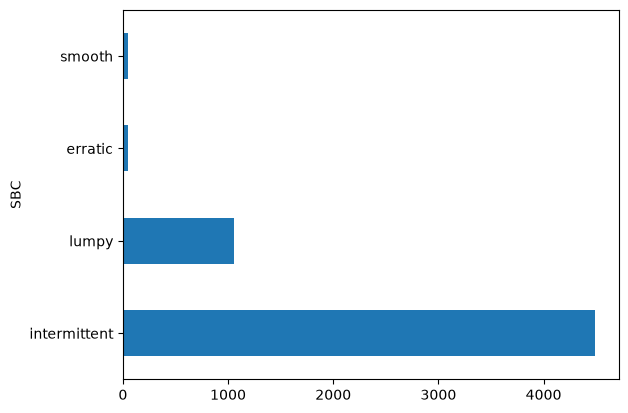

In [74]:
combined_metrics['SBC'].value_counts(sort=True).plot(kind = "barh")

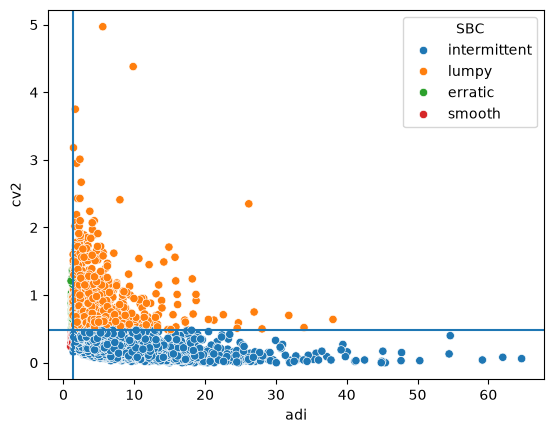

In [75]:
sns.scatterplot(data =combined_metrics ,x = "adi", y = "cv2", hue = "SBC")
plt.axvline(1.32)
plt.axhline(0.49)

<Axes: ylabel='SBC'>

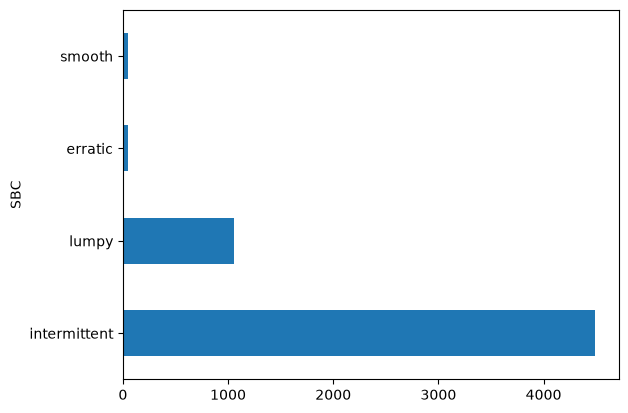

In [76]:
combined_metrics['SBC'].value_counts().plot(kind = "barh")

In [77]:
cv2

id
HOBBIES_1_001_CA_1_evaluation    0.28
HOBBIES_1_001_CA_2_evaluation    0.27
HOBBIES_1_001_CA_3_evaluation    0.30
HOBBIES_1_001_CA_4_evaluation    0.29
HOBBIES_1_001_TX_1_evaluation    0.20
                                 ... 
HOBBIES_2_149_TX_2_evaluation    0.98
HOBBIES_2_149_TX_3_evaluation    0.60
HOBBIES_2_149_WI_1_evaluation    0.44
HOBBIES_2_149_WI_2_evaluation    0.61
HOBBIES_2_149_WI_3_evaluation    0.30
Length: 5650, dtype: float64

In [78]:
# Item price variation
clean_sprice = s3[s3['sell_price'].notna()]
sp = clean_sprice[clean_sprice['sell_price'] > 0]
sp

,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,sell_price,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
date,,,,,,,,,,,,,,,,,,,,,
2011-01-29,HOBBIES_1_008_CA_1_evaluation,HOBBIES_1_008,HOBBIES_1,HOBBIES,CA_1,CA,1,12,11101,0.46,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_009_CA_1_evaluation,HOBBIES_1_009,HOBBIES_1,HOBBIES,CA_1,CA,1,2,11101,1.56,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_010_CA_1_evaluation,HOBBIES_1_010,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,3.17,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_012_CA_1_evaluation,HOBBIES_1_012,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,5.98,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
2011-01-29,HOBBIES_1_015_CA_1_evaluation,HOBBIES_1_015,HOBBIES_1,HOBBIES,CA_1,CA,1,4,11101,0.70,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-22,HOBBIES_2_145_WI_3_evaluation,HOBBIES_2_145,HOBBIES_2,HOBBIES,WI_3,WI,1941,0,11617,2.88,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
2016-05-22,HOBBIES_2_146_WI_3_evaluation,HOBBIES_2_146,HOBBIES_2,HOBBIES,WI_3,WI,1941,0,11617,1.97,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0
2016-05-22,HOBBIES_2_147_WI_3_evaluation,HOBBIES_2_147,HOBBIES_2,HOBBIES,WI_3,WI,1941,0,11617,0.97,...,2,5,2016,NaN,NaN,NaN,NaN,0,0,0


In [79]:
item_pvariation = sp.groupby('id')['sell_price'].agg(['std', 'mean'])
item_pvariation

,std,mean
id,,
HOBBIES_1_001_CA_1_evaluation,0.153150,8.282737
HOBBIES_1_001_CA_2_evaluation,0.024267,8.265121
HOBBIES_1_001_CA_3_evaluation,0.024189,8.265087
HOBBIES_1_001_CA_4_evaluation,0.186164,8.291579
HOBBIES_1_001_TX_1_evaluation,0.287700,8.247005
...,...,...
HOBBIES_2_149_TX_2_evaluation,0.724030,1.523134
HOBBIES_2_149_TX_3_evaluation,0.736841,1.511181
HOBBIES_2_149_WI_1_evaluation,0.720373,1.510162


In [80]:
itemv_2 = (item_pvariation['std']/ item_pvariation['mean']) ** 2
itemv_2

id
HOBBIES_1_001_CA_1_evaluation    0.000342
HOBBIES_1_001_CA_2_evaluation    0.000009
HOBBIES_1_001_CA_3_evaluation    0.000009
HOBBIES_1_001_CA_4_evaluation    0.000504
HOBBIES_1_001_TX_1_evaluation    0.001217
                                   ...   
HOBBIES_2_149_TX_2_evaluation    0.225963
HOBBIES_2_149_TX_3_evaluation    0.237747
HOBBIES_2_149_WI_1_evaluation    0.227545
HOBBIES_2_149_WI_2_evaluation    0.234652
HOBBIES_2_149_WI_3_evaluation    0.231116
Length: 5650, dtype: float64

# Chart shows CV^2 is lesser among the items.
Conclusion: Walmart doesn't change prices often when SNAP days

<Axes: ylabel='Frequency'>

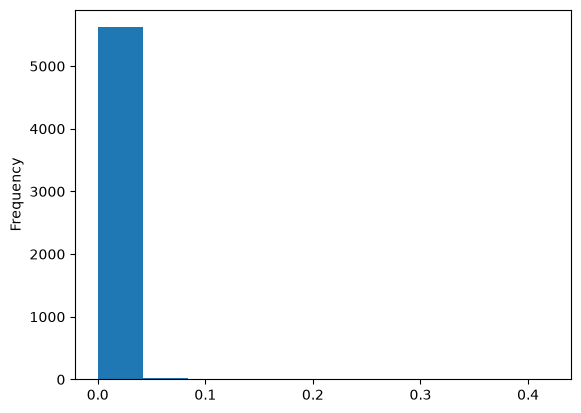

In [81]:
itemv_2.plot(kind = "hist")

In [82]:
s3['snap_CA'].value_counts()

snap_CA
0    7350650
1    3616000
Name: count, dtype: int64

In [83]:
conditions = [
    s3['state_id'] == 'CA',
    s3['state_id'] == 'TX',
    s3['state_id'] == 'WI'
]

choices = [
    s3['snap_CA'],
    s3['snap_TX'],
    s3['snap_WI']
]

s3['snap'] = np.select(conditions, choices)

In [84]:
# No missing
s3['units'].isna().sum()

np.int64(0)

<Axes: ylabel='store_id,snap'>

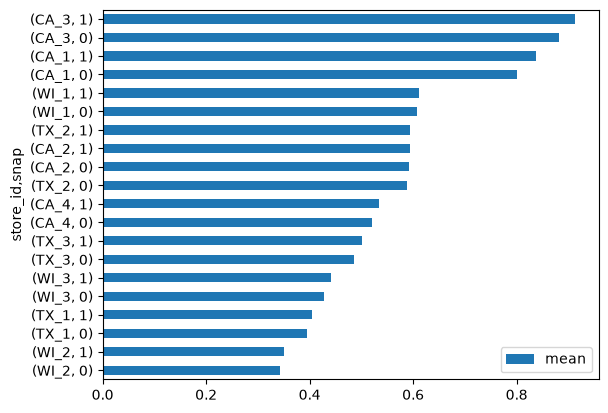

In [85]:
s3.groupby(['store_id', 'snap'])['units'].agg(['mean']).sort_values(by="mean").plot(kind = 'barh')

In [86]:
df = s3.reset_index().sort_values(['id', 'date'])
df = df.reset_index(drop = True)
df.head()

,date,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,snap
0,2011-01-29,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,1,0,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
1,2011-01-30,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,2,0,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
2,2011-01-31,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,3,0,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,0
3,2011-02-01,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,4,0,11101,...,2,2011,NaN,NaN,NaN,NaN,1,1,0,1
4,2011-02-02,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,5,0,11101,...,2,2011,NaN,NaN,NaN,NaN,1,0,1,1


In [87]:
g = df.groupby('id', observed = True)['units']

In [88]:
df['lag_7'] = g.shift(7)
df['lag_28'] = g.shift(28)
df['lag_180'] = g.shift(180)
df['lag_365'] = g.shift(364)

In [89]:
df['rmean_7'] = g.shift(7).rolling(7).mean()
df['rmean_28'] = g.shift(28).rolling(28).mean()
df['rmean_180'] = g.shift(180).rolling(180).mean()
df['rmean_365'] = g.shift(365).rolling(365).mean()

In [90]:
df.columns

Index(['date', 'id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
       'd', 'units', 'wm_yr_wk', 'sell_price', 'Revenue Generated', 'wday',
       'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2',
       'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'snap', 'lag_7',
       'lag_28', 'lag_180', 'lag_365', 'rmean_7', 'rmean_28', 'rmean_180',
       'rmean_365'],
      dtype='str')

In [91]:
s3.index

DatetimeIndex(['2011-01-29', '2011-01-29', '2011-01-29', '2011-01-29',
               '2011-01-29', '2011-01-29', '2011-01-29', '2011-01-29',
               '2011-01-29', '2011-01-29',
               ...
               '2016-05-22', '2016-05-22', '2016-05-22', '2016-05-22',
               '2016-05-22', '2016-05-22', '2016-05-22', '2016-05-22',
               '2016-05-22', '2016-05-22'],
              dtype='datetime64[us]', name='date', length=10966650, freq=None)

<Axes: xlabel='date'>

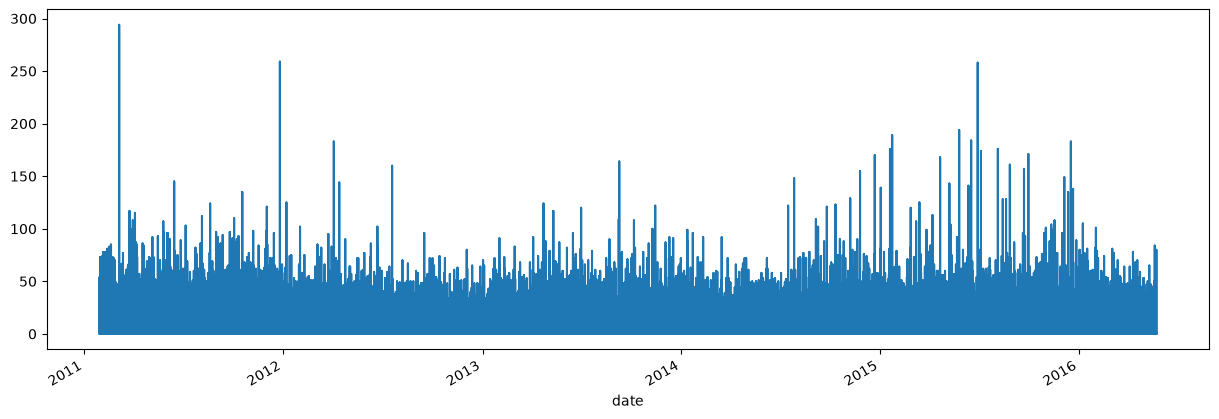

In [92]:
s3['units'].plot(kind='line',figsize = (15, 5))

In [93]:
df['wday'].value_counts()

wday
1    1570700
2    1570700
3    1565050
4    1565050
5    1565050
6    1565050
7    1565050
Name: count, dtype: int64

In [94]:
# Getting the week number of the year
df['week'] = df['date'].dt.isocalendar().week.astype(int)

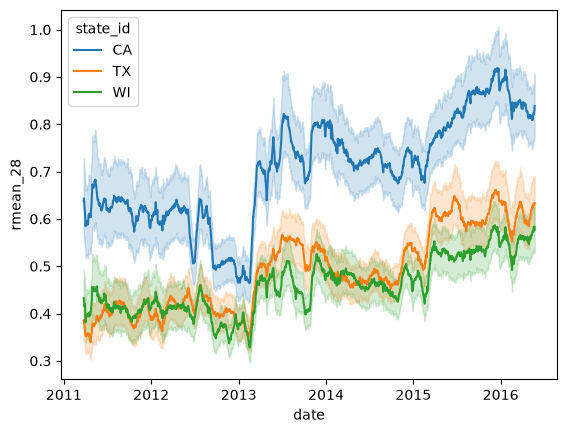

In [95]:
sns.lineplot(data = df, x = "date", y = "rmean_28", hue='state_id')
plt.figsize = (15, 5)

In [96]:
df['is_weekend'] = (df['wday'] >= 5).astype(int)

In [97]:
df[['lag_7','lag_28', 'lag_180', 'lag_365',
    'rmean_7','rmean_28','rmean_180','rmean_365']].isna().sum()

lag_7          39550
lag_28        158200
lag_180      1017000
lag_365      2056600
rmean_7        73450
rmean_28      310750
rmean_180    2028350
rmean_365    4118850
dtype: int64

In [98]:
s3['event'] = s3['event_type_1'].fillna(s3['event_type_2'])

In [105]:
s3['event'].value_counts().sum()

np.int64(892700)

In [ ]:
df['has_event'] = df['event_type_1'].notna().astype(int)
df.groupby('has_event')['units'].mean()

event_days = df[df['has_event'] == 1].groupby('event_type_1')['sell_price'].agg(['std', 'mean'])
event_days['cv2'] = (event_days['std'] / event_days['mean']) ** 2

no_event_cv2 = df[df['has_event'] == 0]['sell_price']
baseline = (no_event_cv2.std() / no_event_cv2.mean()) ** 2

print(event_days[['cv2']])
print('Baseline (no event):', baseline)

                   cv2
event_type_1          
Cultural      0.814886
National      0.820971
Religious     0.816361
Sporting      0.809780
Baseline (no event): 0.8186965556796858


In [100]:
df['has_event'] = df['event_type_1'].notna().astype(int)
df.groupby('has_event')['units'].mean()

has_event
0    0.573128
1    0.523130
Name: units, dtype: float64

In [101]:
event_days = df[df['has_event'] == 1].groupby('event_type_1')['sell_price'].agg(['std', 'mean'])
event_days['cv2'] = (event_days['std'] / event_days['mean']) ** 2

no_event_cv2 = df[df['has_event'] == 0]['sell_price']
baseline = (no_event_cv2.std() / no_event_cv2.mean()) ** 2

print(event_days[['cv2']])
print('Baseline (no event):', baseline)

                   cv2
event_type_1          
Cultural      0.814886
National      0.820971
Religious     0.816361
Sporting      0.809780
Baseline (no event): 0.8186965556796858


In [102]:
# # Item price variation

# sp = clean_sprice[clean_sprice['sell_price'] > 0]
# sp
# item_pvariation = sp.groupby('id')['sell_price'].agg(['std', 'mean'])
# item_pvariation
# itemv_2 = (item_pvariation['std']/ item_pvariation['mean']) ** 2
# itemv_2

In [106]:
event_days = df[df['has_event'] == 1].groupby('event_type_1')['units'].agg(['std', 'mean'])
event_days['cv2_units'] = (event_days['std'] / event_days['mean']) ** 2

no_event_cv2 = df[df['has_event'] == 0]['units']
baseline = (no_event_cv2.std() / no_event_cv2.mean()) ** 2

print(event_days[['cv2_units']])
print('Baseline (no event):', baseline)

              cv2_units
event_type_1           
Cultural      12.243866
National      15.456704
Religious     12.564025
Sporting      12.403786
Baseline (no event): 12.76635776525628


In [110]:
print(df.groupby('has_event')['sell_price'].mean())
print(df.groupby('has_event')['units'].mean())

has_event
0    5.329986
1    5.325385
Name: sell_price, dtype: float64
has_event
0    0.573128
1    0.523130
Name: units, dtype: float64


In [116]:
df.tail()

,date,id,item_id,dept_id,cat_id,store_id,state_id,d,units,wm_yr_wk,...,lag_28,lag_180,lag_365,rmean_7,rmean_28,rmean_180,rmean_365,week,is_weekend,has_event
10966645,2016-05-18,HOBBIES_2_149_WI_3_evaluation,HOBBIES_2_149,HOBBIES_2,HOBBIES,WI_3,WI,1937,0,11616,...,2.0,0.0,0.0,0.428571,0.178571,0.327778,0.167123,20,1,0
10966646,2016-05-19,HOBBIES_2_149_WI_3_evaluation,HOBBIES_2_149,HOBBIES_2,HOBBIES,WI_3,WI,1938,0,11616,...,0.0,0.0,0.0,0.142857,0.142857,0.327778,0.167123,20,1,0
10966647,2016-05-20,HOBBIES_2_149_WI_3_evaluation,HOBBIES_2_149,HOBBIES_2,HOBBIES,WI_3,WI,1939,0,11616,...,0.0,0.0,1.0,0.285714,0.142857,0.316667,0.167123,20,1,0
10966648,2016-05-21,HOBBIES_2_149_WI_3_evaluation,HOBBIES_2_149,HOBBIES_2,HOBBIES,WI_3,WI,1940,0,11617,...,0.0,0.0,1.0,0.285714,0.142857,0.316667,0.169863,20,0,0
10966649,2016-05-22,HOBBIES_2_149_WI_3_evaluation,HOBBIES_2_149,HOBBIES_2,HOBBIES,WI_3,WI,1941,0,11617,...,0.0,0.0,0.0,0.285714,0.142857,0.316667,0.172603,20,0,0


In [111]:
df.columns.to_list()

['date',
 'id',
 'item_id',
 'dept_id',
 'cat_id',
 'store_id',
 'state_id',
 'd',
 'units',
 'wm_yr_wk',
 'sell_price',
 'Revenue Generated',
 'wday',
 'month',
 'year',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI',
 'snap',
 'lag_7',
 'lag_28',
 'lag_180',
 'lag_365',
 'rmean_7',
 'rmean_28',
 'rmean_180',
 'rmean_365',
 'week',
 'is_weekend',
 'has_event']